### Downstream analysis KAIJU, module: tax_classification_rb
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup -p kaiju
```

In [ ]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(vegan)

In [42]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [43]:
# fixed function
read_kaiju <- function(level) {
  otu <- as.data.frame(read_delim(paste0("./tables/kaiju_gather/",level,"_reads.tsv"), delim = "\t"))
  otu$ID <- paste0("ID", seq_len(nrow(otu)))
  
  taxa <- otu[, c("ID", level)]
  colnames(taxa) <- c("ID", "Taxa_level")
  
  rownames(taxa) <- taxa$ID
  taxa <- taxa %>%
    mutate(
      Taxa_level = str_remove(Taxa_level, ";$"),
      Taxa_level = case_when(
        Taxa_level %in% c(
          "unclassified",
          "Viruses",
          paste0("cannot be assigned to a (non-viral) ", level)
        ) ~ paste(Taxa_level, Taxa_level, Taxa_level, Taxa_level, Taxa_level, sep = ";"),
        TRUE ~ Taxa_level
      )
    ) %>%
    separate(
      Taxa_level,
      into = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"),
      sep = ";",
      fill = "right"
    )
  
  taxa$ID <- NULL
  
  rownames(otu) <- otu$ID
  otu$ID <- NULL
  otu[[level]] <- NULL

  return(list(otu=otu, taxa=taxa))
}

In [44]:
level <- "order"

payload <- read_kaiju(level)

otu <- payload$otu
taxa <- payload$taxa


env <- as.data.frame(read_delim("./cr18_env_geomosaicPlot.csv", 
                  delim = ",", 
                  skip = 1, 
                  locale = locale(decimal_mark = ",")))

rownames(env) <- env$Geomosaic_sample

# Generating Phyloseq Object
phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)


Rows: 319 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): order
dbl (8): CR18_ER180415_F, CR18_ER180415_S, CR18_LE180416_F, CR18_LE180416_S,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8 Columns: 77
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (20): Geomosaic_sample, Geomosaic_sample_type, ExpID, SiteID, Collectio...
dbl  (51): year, latitude, longitude, elevation, temp, ph, spc, do_sat, do, ...
lgl   (5): no3, po4, s, co2_3he, co2_4he
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


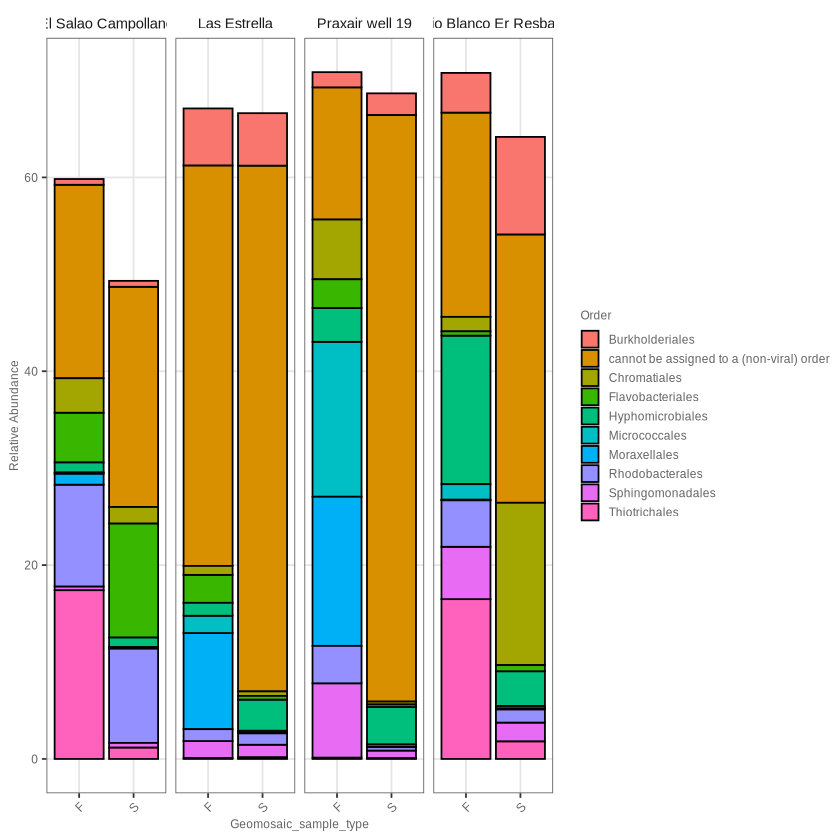

In [45]:
prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) family")))


## Normalizing the asv counts as relative abundances
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100 )

N <- 10
# SORT TOP 10 taxa
top10.family <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
family.top10.ra <- prune_taxa(names(top10.family), prok_ndata_ra)

plot_bar(family.top10.ra, x = "Geomosaic_sample_type", fill="Order") +
  facet_grid(~site_name, scales = "free", space = "free") +
  labs(y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    strip.text.y = element_blank(),  # Rimuove il testo delle righe del facet_grid
    strip.background = element_blank(),  # Rimuove il box di background delle righe del facet_grid
    legend.position = "right",
    panel.grid.major = element_line(color = "grey90")
  )



Principal Coordinate Analysis of the taxonomic diversity plotted using the phyloseq R package. 

In [52]:
run_nmds <- function(phy_obj, level, color_var, shape_var) {
  # phy_obj   : your phyloseq object (already filtered & built)
  # level     : string, e.g. "order", "family" — used only for the plot title
  # color_var : string, metadata column name for point color e.g. "site_name"
  # shape_var : string, metadata column name for point shape e.g. "Geomosaic_sample_type"

  # --- Normalise to relative abundance ---
  phy_ra <- transform_sample_counts(phy_obj, function(x) x / sum(x) * 100)

  # --- Prepare OTU matrix (samples as rows, required by vegan) ---
  otu_matrix <- t(as.matrix(otu_table(phy_ra)))

  # --- Run NMDS ---
  set.seed(123)
  nmds_result <- metaMDS(otu_matrix, distance = "bray", k = 2,
                         trymax = 100, autotransform = FALSE)
  cat("NMDS Stress:", round(nmds_result$stress, 4), "\n")

  # --- Merge scores with metadata ---
  nmds_scores <- as.data.frame(scores(nmds_result, display = "sites"))
  nmds_scores$sample_id <- rownames(nmds_scores)

  metadata_df <- as.data.frame(as.matrix(sample_data(phy_obj)))
  metadata_df$sample_id <- rownames(metadata_df)

  nmds_plot_df <- merge(nmds_scores, metadata_df, by = "sample_id")

  # --- Build plot ---
  stress_label <- paste0("Stress = ", round(nmds_result$stress, 4))
  title_str    <- paste0("NMDS – ", stringr::str_to_title(level), " Level (Bray-Curtis)")

  p <- ggplot(nmds_plot_df, aes(
      x     = NMDS1,
      y     = NMDS2,
      color = .data[[color_var]],   # .data[[]] lets you pass column names as strings
      shape = .data[[shape_var]]
    )) +
    geom_point(size = 3, alpha = 0.85) +
    stat_ellipse(aes(group = .data[[color_var]]),
                 type = "t", level = 0.95,
                 linetype = "dashed", linewidth = 0.4) +
    annotate("text", x = Inf, y = -Inf, label = stress_label,
             hjust = 1.1, vjust = -0.5, size = 3,
             color = rgb(100, 100, 100, maxColorValue = 255)) +
    labs(title = title_str, x = "NMDS1", y = "NMDS2",
         color = stringr::str_to_title(color_var),
         shape = stringr::str_to_title(shape_var)) +
    theme_glab()

  return(p)
}

Run 0 stress 0.05051882 
Run 1 stress 0.05051887 
... Procrustes: rmse 6.20589e-05  max resid 9.210025e-05 
... Similar to previous best
Run 2 stress 0.05915803 
Run 3 stress 0.2102053 
Run 4 stress 0.2012994 
Run 5 stress 0.05915803 
Run 6 stress 0.06001859 
Run 7 stress 0.05915803 
Run 8 stress 0.05915803 
Run 9 stress 0.0505188 
... New best solution
... Procrustes: rmse 3.746912e-05  max resid 6.702265e-05 
... Similar to previous best
Run 10 stress 0.05051881 
... Procrustes: rmse 0.0001546462  max resid 0.000261142 
... Similar to previous best
Run 11 stress 0.1940413 
Run 12 stress 0.05051879 
... New best solution
... Procrustes: rmse 3.309766e-05  max resid 5.435403e-05 
... Similar to previous best
Run 13 stress 0.06001859 
Run 14 stress 0.05051879 
... Procrustes: rmse 2.248789e-05  max resid 3.902016e-05 
... Similar to previous best
Run 15 stress 0.05051879 
... Procrustes: rmse 2.00165e-05  max resid 3.453096e-05 
... Similar to previous best
Run 16 stress 0.1982728 
Run 

Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Too few points to calculate an ellipse
Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_path()`).”


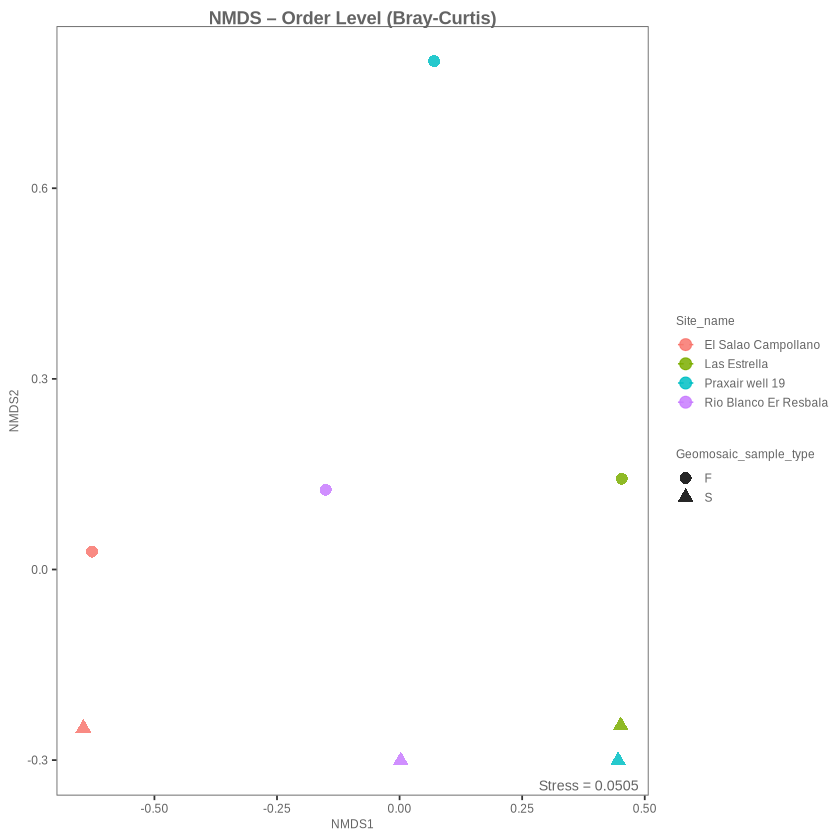

In [53]:
# You already have 'prok' built in your notebook — just pass it in
p_nmds <- run_nmds(
  phy_obj   = prok,
  level     = level,
  color_var = "site_name",
  shape_var = "Geomosaic_sample_type"
)

print(p_nmds)

In [54]:
run_permanova <- function(phy_obj, group_var, permutations = 999) {
  # phy_obj      : phyloseq object (same one passed to run_nmds)
  # group_var    : string, metadata column to test e.g. "site_name"
  # permutations : number of permutations (default 999, increase for publication)

  # --- Normalise (same as NMDS for consistency) ---
  phy_ra <- transform_sample_counts(phy_obj, function(x) x / sum(x) * 100)
  otu_matrix <- t(as.matrix(otu_table(phy_ra)))

  # --- Metadata ---
  metadata_df <- as.data.frame(as.matrix(sample_data(phy_obj)))

  # --- Bray-Curtis dissimilarity ---
  bc_dist <- vegdist(otu_matrix, method = "bray")

  # --- PERMANOVA ---
  formula_str <- as.formula(paste("bc_dist ~", group_var))
  result <- adonis2(formula_str, data = metadata_df, permutations = permutations)

  print(result)
  return(invisible(result))   # returns silently so you can save it if needed
}

In [55]:
# Test
run_permanova(
  phy_obj   = prok,
  group_var = "site_name"
)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = formula_str, data = metadata_df, permutations = permutations)
         Df SumOfSqs      R2      F Pr(>F)
Model     3  0.61327 0.56154 1.7076  0.106
Residual  4  0.47885 0.43846              
Total     7  1.09212 1.00000              
